# **OPTION PRICING UNDER HESTON (MONTE CARLO)**


*In Lesson 2 of Module 7, we will **implement Monte-Carlo pricing** of an option **under Heston model dynamics**.* 

As usual, let's start by importing the necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

## **1. Option Pricing under Heston Using Monte-Carlo Methods**

As you can expect, we will be first replicating the code used in the last lesson on how to simulate underlying stock prices under the following Heston dynamics:
$$
\begin{equation*} 
    S_t = S_{t-1} e^{\left( r - \frac{\nu_t}{2} \right) dt + \sigma \sqrt{\nu_t} dZ_1}
\end{equation*} 
$$
$$
\begin{equation*} 
    \nu_t = \nu_{t-1} + \kappa \left( \theta - \nu_{t-1} \right) dt + \sigma \sqrt{\nu_{t-1}}dZ_2
\end{equation*}
$$
\
So, let's define and run the different functions we needed to simulate stock prices: 

- First, **stochastic volatility**:

In [2]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

- Second, **underlying stock price** path based on stochastic vol:

In [3]:
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

- Third, our function to **generate random numbers** following a standard normal:

In [4]:
def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

We have already  discussed in the slides that one of the problems we will encounter when using Heston is how to set up the different parameters needed by the model. We will spend a lot of time unveiling this in the Stochastic Modeling course. For now, let's assume some given parameters, as we did in Lesson 1:

In [5]:
v0 = 0.04
kappa_v = 2
sigma_v = 0.3
theta_v = 0.04
rho = -0.9

S0 = 100  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 1  # Number of years
M = int(M0*T) # Total time steps
I = 10000  # Nomber of simulations
dt = T/M  # Length of time step

And build our covariance matrix (using Cholesky decomposition to account for correlation between $dZ_1$ and $dZ_2$):

In [6]:
# Generating random numbers from standard normal
rand = random_number_gen(M, I)


# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

So, as in the previous lesson, we can now simulate the stock price paths and stochastic volatility:

In [7]:
# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
S = Heston_paths(S0, r, V, 0, cho_matrix)

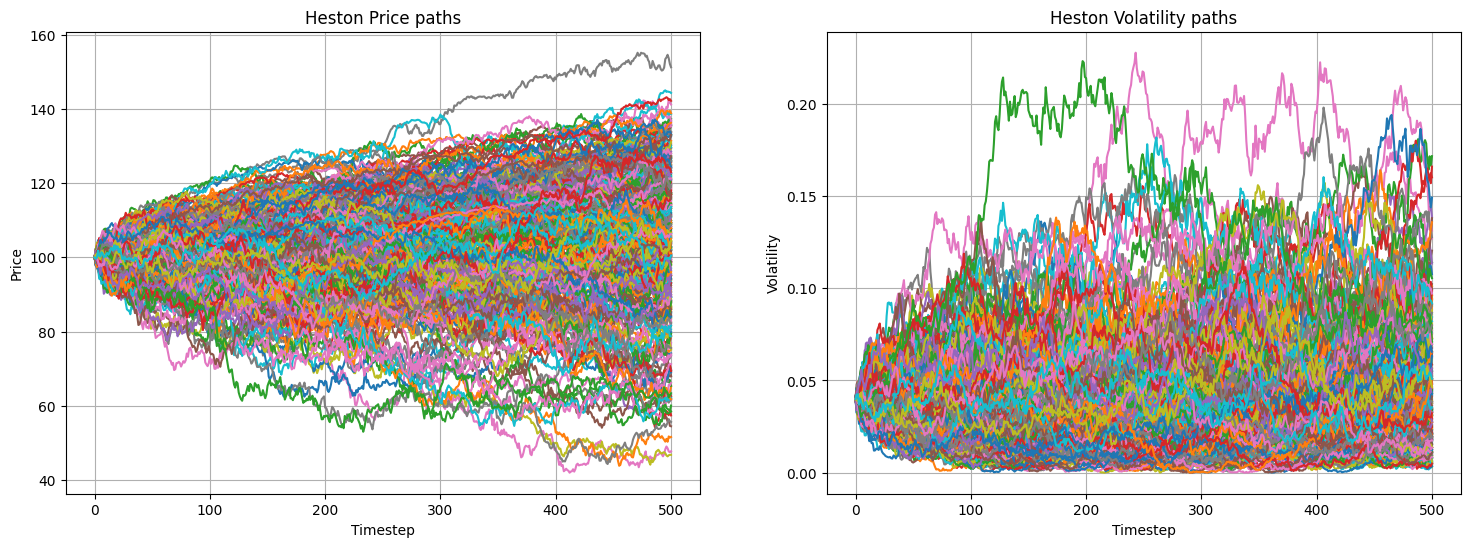

In [8]:
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(300)

Now that we have simulated all the stock prices under Heston, let's define another function that calculates the payoffs and current price of a European call option with the following characteristics:

- $T=1$ year
- $K = 90$
- $r=0.05$
- $S_t \sim$ Heston dynamics

In [9]:
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)

    average = np.mean(payoff)

    return np.exp(-r * (T - t)) * average

Note that you can improve the efficiency of the previous function substantially by implementing a better and more organized function that incorporates the generation of stock price and volatility paths. We recommend you work on this by yourself (it should be fairly easy) in order to work on Group Work Projects and other tasks. At this point, we just want to highlight how we apply the spirit of the Monte-Carlo method in simpler frameworks.

\
So, the price of a European Call option with 1 year maturity and strike $K=90$ (and all the other assumed parameters from before) is...

In [10]:
print("European Call Price under Heston: ", heston_call_mc(S, 90, 0.05, 1, 0))

European Call Price under Heston:  17.276932871289542


## **2. Comparison of Heston Option Price versus Other Methods**

Let's now see how the value of the option via Heston model differs from what we would have under the Black-Scholes framework, for example.

- **Black-Scholes closed-form solution**:

In [11]:
def bs_call_price(S, r, sigma, t, T, K):
    ttm = T - t

    if ttm < 0:
        return 0.0
    elif ttm == 0.0:
        return np.maximum(S - K, 0.0)

    vol = sigma * np.sqrt(ttm)

    d_minus = np.log(S / K) + (r - 0.5 * sigma**2) * ttm
    d_minus /= vol

    d_plus = d_minus + vol

    res = S * ss.norm.cdf(d_plus)
    res -= K * np.exp(-r * ttm) * ss.norm.cdf(d_minus)

    return res

In [12]:
print("European Call Price under BS: ", bs_call_price(100, 0.05, sigma_v, 0, 1, 90))

European Call Price under BS:  19.697442086839736


- **Black-Scholes Monte-Carlo price:**<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [13]:
def bs_call_mc(S, K, r, sigma, T, t, Ite):
    data = np.zeros((Ite, 2))
    z = np.random.normal(0, 1, [1, Ite])
    ST = S * np.exp((T - t) * (r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
    data[:, 1] = ST - K

    average = np.sum(np.amax(data, axis=1)) / float(Ite)

    return np.exp(-r * (T - t)) * average

In [14]:
print(
    "European Call Price under BS (MC): ",
    bs_call_mc(100, 90, 0.05, sigma_v, 1, 0, 10000),
)

European Call Price under BS (MC):  19.447117326986664


Interestingly, we get prices that are very far away from each other. Is this a problem? Does our model not work?

Not at all! At the end of the day, why would the Heston option price converge to Black-Scholes?

- We have already established that BS is an oversimplification of reality (*remember: stylized facts!*)

- Heston (and other models) are just **extending the BS world** to get closer to this reality.

- The latter seems clearer when you look at Lesson 1 and the statistical distribution under Heston. There is more kurtosis and skewness than normal distribution, just as we observe in practice.

- If BS and Heston get to the same output, what is the point of adding mathematical and computational complexity?

There is another important issue related to model specification and parameters:

- In the latter pricing example, we have used a $\sigma=0.3$ for both models. 

- This is not correct, since there is no easy mapping of the volatility parameter from one model to the other. In other words, the $\sigma$ parameter cannot be used interchangeably in Heston or Black-Scholes.

- What is the real $\sigma$ for each model then? Do not worry; we will tackle this issue through calibration in the upcoming Stochastic Modeling course.



## **3. Conclusion**

At the beginning of the course, we introduced a simple framework to work on, i.e., the binomial model. What we have been doing since, essentially, is advancing our understanding towards more complex models that try to capture the different features associated with underlying stock prices and returns. From Black-Scholes to the Heston model, we have merely focused on modeling the underlying price, whereas the intuition on option pricing remained intact. For the final part of the Derivative Pricing course, we will focus on one more stylized fact of stock prices: jumps. 

In the next lesson, we will take a look at jumps in prices, as well as how can we formally model those jumps to incorporate them in our pricing.